# 2.Deliverable

## Part 1: CIFAR-10 Image Classification with AlexNet

### 1. Overview

This project demonstrates an end‑to‑end deep learning pipeline for classifying the **CIFAR-10** dataset using a modified **AlexNet** architecture. The notebook covers data loading, exploratory data analysis, model definition, hyperparameter optimisation with **Optuna**, final training, and evaluation.

In [1]:
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import pandas as pd
import kagglehub
import time

import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader, random_split, RandomSampler, SequentialSampler, Dataset
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets
from torchvision import models
from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights
from PIL import Image 


import optuna
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
import torch.nn.init as init
from models.AlexNet import AlexNetCIFAR

import cv2
import torch.nn.functional as F


/home/jonjauregui/DLproyect/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def unpickle(file):
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

cifar_directory = 'data/cifar' 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")



In [3]:
cifar10_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
                'dog', 'frog', 'horse', 'ship', 'truck']

### 2. Data Preparation

- The CIFAR-10 dataset (50 000 training images, 10 000 test images) is loaded from binary pickle files stored in the `data/` directory.
- Training data is split into a training set (45 000 images) and a validation set (5 000 images) using a fixed random seed (`42`) for reproducibility.
- Standard data augmentation (random horizontal flip, random crop with padding) is applied to the training set. Both training and test images are normalised using the CIFAR-10 channel means and standard deviations.

In [26]:
def load_cifar10_data(data_dir):
    """
    Loads and processes all CIFAR-10 batches from the specified directory.
    """
    train_data = []
    train_labels = []

    # 1. Load the 5 training batches
    for i in range(1, 6):
        filename = os.path.join(data_dir, f'data_batch_{i}')
        batch_dict = unpickle(filename)
        
        train_data.append(batch_dict[b'data'])
        train_labels.extend(batch_dict[b'labels'])

    # 2. Stack the 5 arrays into one massive array of shape (50000, 3072)
    X_train = np.vstack(train_data)
    y_train = np.array(train_labels)

    # 3. Load the 1 testing batch
    test_filename = os.path.join(data_dir, 'test_batch')
    test_dict = unpickle(test_filename)
    
    X_test = test_dict[b'data']
    y_test = np.array(test_dict[b'labels'])

    # 4. Reshape and Transpose the images
    # - reshape(-1, 3, 32, 32) splits the 3072 into 3 channels of 32x32.
    # - transpose(0, 2, 3, 1) shifts the axes from (Batch, Channel, Height, Width) 
    #   to (Batch, Height, Width, Channel), which is what TensorFlow/Keras expect.
    X_train = X_train.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    X_test = X_test.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)

    return (X_train, y_train), (X_test, y_test)

In [27]:
(X_train, y_train), (X_test, y_test) = load_cifar10_data(cifar_directory)

/tmp/ipykernel_1657/3048791060.py:3: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  dict = pickle.load(fo, encoding='bytes')


### 3. Exploratory Data Analysis (EDA)

Key observations from the EDA:
- **Dataset size**: 50 000 training images of shape `(32, 32, 3)`, 5 000 reserved for validation.
- **Class balance**: Each of the 10 classes contains exactly 5 000 images. No class imbalance is present.
- **Pixel values**: Range from 0 to 255 (uint8), typical for RGB images.
- **Sample visualisation**: A grid of 10 random training images was displayed, confirming the low‑resolution (32×32) nature of the dataset and the variety of objects.

In [28]:
def perform_cifar10_eda(X_train, y_train):
    print("--- Starting CIFAR-10 Exploratory Data Analysis ---\n")
    
    # 1. Dataset Shape and Data Types
    print(f"Training Data Shape: {X_train.shape}")
    print(f"Training Labels Shape: {y_train.shape}")
    print(f"Data Type: {X_train.dtype}")
    print(f"Min Pixel Value: {X_train.min()} | Max Pixel Value: {X_train.max()}\n")

    # 2. Class Distribution
    # Count how many images belong to each class
    unique_classes, counts = np.unique(y_train, return_counts=True)
    
    plt.figure(figsize=(10, 5))
    sns.barplot(x=[cifar10_classes[i] for i in unique_classes], y=counts, palette="viridis")
    plt.title('Distribution of Classes in CIFAR-10 Training Set')
    plt.xlabel('Class')
    plt.ylabel('Number of Images')
    plt.show()
    
    print("Class counts:")
    for cls, count in zip(unique_classes, counts):
        print(f"{cifar10_classes[cls]}: {count}")
    print("\n")

    # 3. Visualizing Sample Images
    # Display the first 10 images from the training set
    plt.figure(figsize=(15, 3))
    for i in range(10):
        plt.subplot(1, 10, i + 1)
        # We need to ensure data is an integer between 0-255 for standard plotting
        img = X_train[i]
        if img.max() <= 1.0:
            img = (img * 255).astype(np.uint8)
            
        plt.imshow(img)
        plt.title(cifar10_classes[y_train[i]])
        plt.axis('off')
    plt.suptitle('Sample Images from CIFAR-10', fontsize=16)
    plt.tight_layout()
    plt.show()

# 4.Color Channel Analysis
    colors = ('red', 'green', 'blue')
    plt.figure(figsize=(10, 4))
    for i, col in enumerate(colors):
        # Calculamos el histograma para cada canal (R, G, B)
        hist, bin_edges = np.histogram(X_train[:, :, :, i], bins=256, range=(0, 255))
        plt.plot(bin_edges[0:-1], hist, color=col, label=f'Channel {col}')
    plt.title('Color Intensity Distribution')
    plt.xlabel('Pixel Value (0-255)')
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()

/tmp/ipykernel_1657/207254444.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[cifar10_classes[i] for i in unique_classes], y=counts, palette="viridis")


--- Starting CIFAR-10 Exploratory Data Analysis ---

Training Data Shape: (50000, 32, 32, 3)
Training Labels Shape: (50000,)
Data Type: uint8
Min Pixel Value: 0 | Max Pixel Value: 255



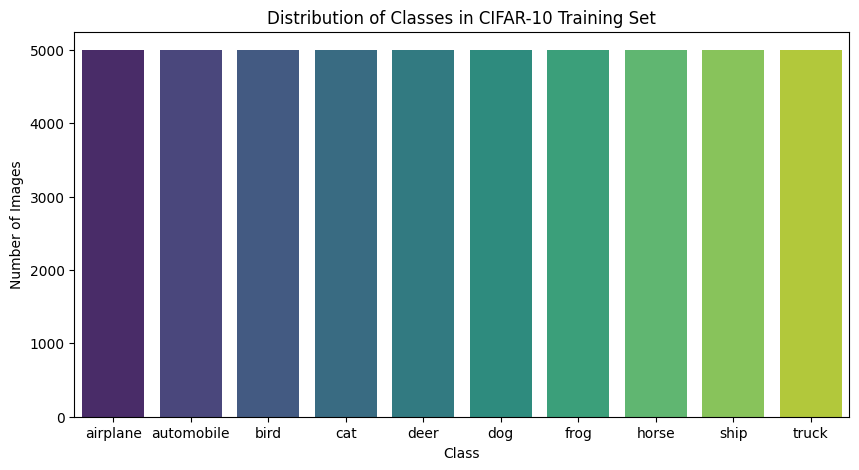

Class counts:
airplane: 5000
automobile: 5000
bird: 5000
cat: 5000
deer: 5000
dog: 5000
frog: 5000
horse: 5000
ship: 5000
truck: 5000




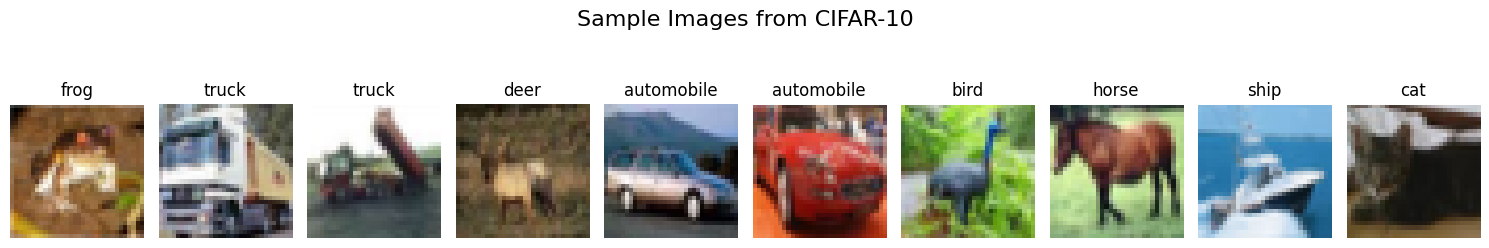

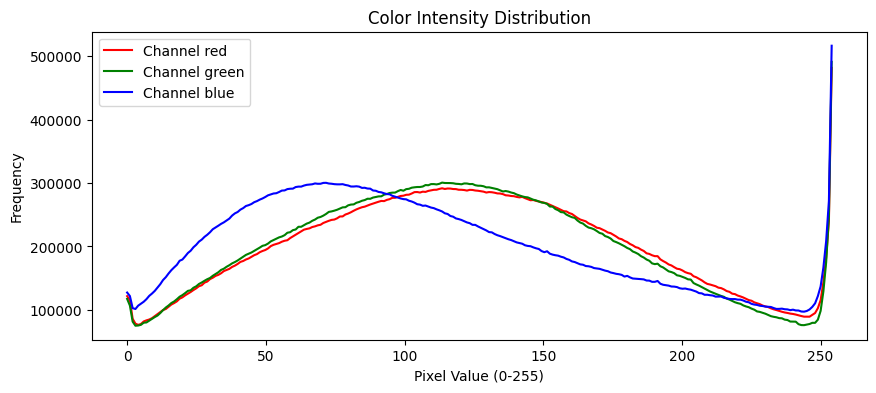

In [29]:
perform_cifar10_eda(X_train, y_train)

### 4. Model Architecture – AlexNetCIFAR

A custom implementation of **AlexNet** adapted for CIFAR-10:
- **Input**: 32×32×3 images.
- **Convolutional layers**: 5 convolutional blocks with kernel sizes of 3×3 (instead of the original 11×11 and 5×5 to better suit small images). Each block is followed by batch normalisation and ReLU activation.
- **Pooling**: Max pooling with 2×2 windows.
- **Classifier**: Three fully‑connected layers (4096 → 4096 → 10), with dropout regularisation between them.
- **Dropout rate** is a tunable hyperparameter, optimised together with other parameters.

In [30]:
# Enable cuDNN benchmarking for faster convolutions
torch.backends.cudnn.benchmark = True

# CIFAR-10 constants
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2470, 0.2435, 0.2616)

# Transforms (keep the rest of your transforms exactly the same below this...)
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
])

In [31]:
  
class CIFAR10FromNumpy(Dataset):
    """A simple Dataset wrapper for CIFAR‑10 stored as NumPy arrays."""
    def __init__(self, images, labels, transform=None):
        self.images = images          # shape: (N, 32, 32, 3), dtype uint8
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]                # (32, 32, 3) uint8
        label = self.labels[idx]

        # Convert to a PIL Image first (torchvision transforms expect PIL)
        img = Image.fromarray(img)

        if self.transform is not None:
            img = self.transform(img)
        else:
            # Fallback: just convert to tensor (HWC -> CHW)
            img = torch.from_numpy(np.array(img)).permute(2, 0, 1).float()

        return img, label

# Load the data from the existing 'data' directory – NO download
(X_train, y_train), (X_test, y_test) = load_cifar10_data('data/cifar')

# Split training data into actual training and validation (as before)
train_size = 45000
val_size = 5000
generator = torch.Generator().manual_seed(42)

full_train_dataset = CIFAR10FromNumpy(X_train, y_train, transform=transform_train)

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=generator
)

test_set = CIFAR10FromNumpy(X_test, y_test, transform=transform_test)

print(f"Training set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")

Training set size: 45000
Validation set size: 5000


/tmp/ipykernel_1657/3048791060.py:3: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  dict = pickle.load(fo, encoding='bytes')


In [32]:
from torchmetrics import Accuracy
import torch

def train_one_epoch(model, loader, optimizer, criterion, device, scaler):
    model.train()
    acc_metric = Accuracy(task='multiclass', num_classes=10).to(device)
    running_loss = 0.0
    
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        
        # 1. Cast operations to mixed precision
        with torch.autocast(device_type='cuda', dtype=torch.float16):
            outputs = model(images)
            loss = criterion(outputs, labels)
        
        # 2. Scale the loss and call backward
        scaler.scale(loss).backward()
        
        # 3. Step the optimizer and update scaler
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item() * images.size(0)
        acc_metric.update(outputs, labels)
        
    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc  = acc_metric.compute().item()
    acc_metric.reset()
    return epoch_loss, epoch_acc

def evaluate(model, loader, criterion, device):
    model.eval()
    acc_metric = Accuracy(task='multiclass', num_classes=10).to(device)
    running_loss = 0.0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            acc_metric.update(outputs, labels)
    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc  = acc_metric.compute().item()
    acc_metric.reset()
    return epoch_loss, epoch_acc

### 5. Hyperparameter Optimisation (Optuna)

Now we are going to make a study and with optuna we are going to select the best hyperparameter for our dataset. We have defined the intervals of some of the hyperparameters that our model uses.

In [33]:
def objective(trial):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Initialize Mixed Precision Scaler
    scaler = torch.amp.GradScaler('cuda')

    # ---- Hyperparameters to tune ----
    batch_size = trial.suggest_categorical("batch_size", [64, 128, 256])
    lr = trial.suggest_float("lr", 1e-4, 5e-2, log=True)
    optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "SGD"])
    dropout_rate = trial.suggest_float("dropout_rate", 0.2, 0.7)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)

    if optimizer_name == "SGD":
        momentum = trial.suggest_float("momentum", 0.5, 0.99)
        use_nesterov = trial.suggest_categorical("nesterov", [True, False])
    else:  # Adam
        beta1 = trial.suggest_float("beta1", 0.8, 0.999)
        beta2 = trial.suggest_float("beta2", 0.9, 0.9999)

    init_method = trial.suggest_categorical("init_method", ["kaiming_normal", "xavier_normal"])

    # ---- Build model ----
    model = AlexNetCIFAR(num_classes=10, dropout_rate=dropout_rate).to(device)

    # Apply weight initialization
    def apply_init(m):
        if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
            if init_method == "kaiming_normal":
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            else:
                nn.init.xavier_normal_(m.weight)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
    model.apply(apply_init)
    

    train_loader = DataLoader(
        train_dataset, batch_size=batch_size,
        sampler=RandomSampler(train_dataset),
        num_workers=8,  
        pin_memory=True,
        persistent_workers=True 
    )

    val_loader = DataLoader(
        val_dataset, batch_size=batch_size,
        sampler=SequentialSampler(val_dataset),
        num_workers=8,  
        pin_memory=True,
        persistent_workers=True 
    )

    # ---- Optimizer ----
    if optimizer_name == "Adam":
        optimizer = optim.Adam(
            model.parameters(), lr=lr,
            weight_decay=weight_decay,
            betas=(beta1, beta2)
        )
    else:  # SGD
        optimizer = optim.SGD(
            model.parameters(), lr=lr,
            momentum=momentum, weight_decay=weight_decay,
            nesterov=use_nesterov
        )

    criterion = nn.CrossEntropyLoss()
    scheduler = StepLR(optimizer, step_size=15, gamma=0.1)

    N_EPOCHS = 15
    
    for epoch in range(N_EPOCHS):
        # Pass the scaler into train_one_epoch
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device, scaler)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        scheduler.step()

        print(f"Trial {trial.number}, Epoch {epoch+1:2d}/{N_EPOCHS}: "
              f"Train Acc {train_acc:.2f}%, Val Acc {val_acc:.2f}%")   
        
        # Report intermediate value for pruning
        trial.report(val_acc, epoch)

        # Handle pruning based on validation accuracy
        if trial.should_prune():
            raise optuna.TrialPruned()

    return val_acc

In [12]:
# Create a study with a SQLite database to store all results
storage_url = "sqlite:///saved/cifar_alexnet_study.db"

study = optuna.create_study(
    study_name="cifar_alexnet",
    direction="maximize",
    storage=storage_url,
    load_if_exists=True,
    sampler=TPESampler(seed=42),
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=10)
)

# Run for, say, 50 trials (adjust based on time)
study.optimize(objective, n_trials=10, timeout=None)

[I 2026-04-30 16:09:45,321] A new study created in RDB with name: cifar_alexnet


Trial 0, Epoch  1/15: Train Acc 0.17%, Val Acc 0.12%
Trial 0, Epoch  2/15: Train Acc 0.36%, Val Acc 0.39%
Trial 0, Epoch  3/15: Train Acc 0.51%, Val Acc 0.41%
Trial 0, Epoch  4/15: Train Acc 0.59%, Val Acc 0.57%
Trial 0, Epoch  5/15: Train Acc 0.62%, Val Acc 0.58%
Trial 0, Epoch  6/15: Train Acc 0.63%, Val Acc 0.61%
Trial 0, Epoch  7/15: Train Acc 0.65%, Val Acc 0.58%
Trial 0, Epoch  8/15: Train Acc 0.66%, Val Acc 0.59%
Trial 0, Epoch  9/15: Train Acc 0.66%, Val Acc 0.66%
Trial 0, Epoch 10/15: Train Acc 0.67%, Val Acc 0.66%
Trial 0, Epoch 11/15: Train Acc 0.68%, Val Acc 0.61%
Trial 0, Epoch 12/15: Train Acc 0.68%, Val Acc 0.59%
Trial 0, Epoch 13/15: Train Acc 0.68%, Val Acc 0.67%
Trial 0, Epoch 14/15: Train Acc 0.69%, Val Acc 0.67%


[I 2026-04-30 16:12:21,443] Trial 0 finished with value: 0.6488000154495239 and parameters: {'batch_size': 128, 'lr': 0.004128205343826225, 'optimizer': 'Adam', 'dropout_rate': 0.22904180608409974, 'weight_decay': 0.0029154431891537554, 'beta1': 0.9196218873368985, 'beta2': 0.970736450521825, 'init_method': 'xavier_normal'}. Best is trial 0 with value: 0.6488000154495239.


Trial 0, Epoch 15/15: Train Acc 0.69%, Val Acc 0.65%
Trial 1, Epoch  1/15: Train Acc 0.30%, Val Acc 0.43%
Trial 1, Epoch  2/15: Train Acc 0.41%, Val Acc 0.48%
Trial 1, Epoch  3/15: Train Acc 0.46%, Val Acc 0.52%
Trial 1, Epoch  4/15: Train Acc 0.50%, Val Acc 0.55%
Trial 1, Epoch  5/15: Train Acc 0.53%, Val Acc 0.58%
Trial 1, Epoch  6/15: Train Acc 0.56%, Val Acc 0.59%
Trial 1, Epoch  7/15: Train Acc 0.58%, Val Acc 0.62%
Trial 1, Epoch  8/15: Train Acc 0.60%, Val Acc 0.63%
Trial 1, Epoch  9/15: Train Acc 0.62%, Val Acc 0.65%
Trial 1, Epoch 10/15: Train Acc 0.63%, Val Acc 0.66%
Trial 1, Epoch 11/15: Train Acc 0.64%, Val Acc 0.66%
Trial 1, Epoch 12/15: Train Acc 0.65%, Val Acc 0.68%
Trial 1, Epoch 13/15: Train Acc 0.66%, Val Acc 0.68%
Trial 1, Epoch 14/15: Train Acc 0.67%, Val Acc 0.69%


[I 2026-04-30 16:15:22,408] Trial 1 finished with value: 0.6890000104904175 and parameters: {'batch_size': 64, 'lr': 0.0003126102910311062, 'optimizer': 'SGD', 'dropout_rate': 0.4159725093210579, 'weight_decay': 1.461896279370496e-05, 'momentum': 0.7998079184139659, 'nesterov': False, 'init_method': 'xavier_normal'}. Best is trial 1 with value: 0.6890000104904175.


...

Trial 7, Epoch 11/15: Train Acc 0.59%, Val Acc 0.61%
Trial 8, Epoch  1/15: Train Acc 0.20%, Val Acc 0.26%
Trial 8, Epoch  2/15: Train Acc 0.42%, Val Acc 0.46%
Trial 8, Epoch  3/15: Train Acc 0.54%, Val Acc 0.55%
Trial 8, Epoch  4/15: Train Acc 0.62%, Val Acc 0.56%
Trial 8, Epoch  5/15: Train Acc 0.67%, Val Acc 0.66%
Trial 8, Epoch  6/15: Train Acc 0.70%, Val Acc 0.64%
Trial 8, Epoch  7/15: Train Acc 0.72%, Val Acc 0.66%
Trial 8, Epoch  8/15: Train Acc 0.73%, Val Acc 0.71%
Trial 8, Epoch  9/15: Train Acc 0.74%, Val Acc 0.70%
Trial 8, Epoch 10/15: Train Acc 0.75%, Val Acc 0.74%
Trial 8, Epoch 11/15: Train Acc 0.75%, Val Acc 0.72%
Trial 8, Epoch 12/15: Train Acc 0.76%, Val Acc 0.75%
Trial 8, Epoch 13/15: Train Acc 0.77%, Val Acc 0.74%
Trial 8, Epoch 14/15: Train Acc 0.77%, Val Acc 0.73%


[I 2026-04-30 16:32:26,282] Trial 8 finished with value: 0.7184000015258789 and parameters: {'batch_size': 128, 'lr': 0.002358397688593216, 'optimizer': 'Adam', 'dropout_rate': 0.4051914615178148, 'weight_decay': 0.001052457468133564, 'beta1': 0.8455308349328329, 'beta2': 0.9076902929918964, 'init_method': 'kaiming_normal'}. Best is trial 4 with value: 0.8126000165939331.


Trial 8, Epoch 15/15: Train Acc 0.77%, Val Acc 0.72%
Trial 9, Epoch  1/15: Train Acc 0.11%, Val Acc 0.10%
Trial 9, Epoch  2/15: Train Acc 0.11%, Val Acc 0.10%
Trial 9, Epoch  3/15: Train Acc 0.11%, Val Acc 0.10%
Trial 9, Epoch  4/15: Train Acc 0.11%, Val Acc 0.10%
Trial 9, Epoch  5/15: Train Acc 0.11%, Val Acc 0.10%
Trial 9, Epoch  6/15: Train Acc 0.11%, Val Acc 0.10%
Trial 9, Epoch  7/15: Train Acc 0.11%, Val Acc 0.10%
Trial 9, Epoch  8/15: Train Acc 0.11%, Val Acc 0.10%
Trial 9, Epoch  9/15: Train Acc 0.11%, Val Acc 0.10%
Trial 9, Epoch 10/15: Train Acc 0.11%, Val Acc 0.10%


[I 2026-04-30 16:33:43,787] Trial 9 pruned. 


Trial 9, Epoch 11/15: Train Acc 0.11%, Val Acc 0.10%


In [34]:
storage_url = "sqlite:///saved/cifar_alexnet_study.db"
study = optuna.load_study(study_name="cifar_alexnet", storage=storage_url)

best_trial = study.best_trial
print("Best validation accuracy: {:.4f}".format(best_trial.value))
print("Best hyperparameters:")
for key, value in best_trial.params.items():
    print(f"  {key}: {value}")

# Hyperparameter importance (requires some completed trials)
importances = optuna.importance.get_param_importances(study)
print("\nHyperparameter importances:")
for param, imp in importances.items():
    print(f"  {param:20s}: {imp:.4f}")

Best validation accuracy: 0.8126
Best hyperparameters:
  batch_size: 128
  lr: 0.004108791545324082
  optimizer: Adam
  dropout_rate: 0.2979914312095726
  weight_decay: 1.5167330688076198e-06
  beta1: 0.8647407358218896
  beta2: 0.9388288612399793
  init_method: xavier_normal

Hyperparameter importances:
  dropout_rate        : 0.4608
  weight_decay        : 0.2123
  lr                  : 0.1170
  init_method         : 0.0989
  optimizer           : 0.0911
  batch_size          : 0.0198



Using **Optuna** with a TPE sampler and median pruner, we searched for the best combination of:
- Batch size, learning rate, optimiser (Adam / SGD)
- Dropout rate, weight decay
- Weight initialisation method (Kaiming Normal / Xavier Normal)
- For SGD: momentum and Nesterov; for Adam: β₁, β₂

The study ran over **10 trials** (with the potential to extend) and was stored in an SQLite database. The best trial achieved a **validation accuracy of 81.26%** with the following optimal hyperparameters:

| Parameter       | Value                  |
|-----------------|------------------------|
| Batch size      | 128                    |
| Learning rate   | 4.11 × 10⁻³            |
| Optimiser       | Adam                   |
| Dropout rate    | 0.297                  |
| Weight decay    | 1.52 × 10⁻⁶            |
| β₁ (Adam)       | 0.865                  |
| β₂ (Adam)       | 0.939                  |
| Init method     | Xavier Normal          |

Hyperparameter importance analysis indicated that **dropout rate** had the largest impact on validation accuracy, followed by learning rate and weight decay.


### 6. Final Model Training

The best hyperparameters were used to retrain the model on the **full 50 000 training images** for 30 epochs. The best checkpoint (based on test accuracy) was saved to `saved/best_alexnet_cifar.pth`.

In [35]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

best_params = best_trial.params

# Create final model with best dropout_rate
final_dropout = best_params["dropout_rate"]
model = AlexNetCIFAR(num_classes=10, dropout_rate=final_dropout).to(device)

# Apply best init method
init_method = best_params["init_method"]
def apply_init(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
        if init_method == "kaiming_normal":
            nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
        else:
            nn.init.xavier_normal_(m.weight)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)
model.apply(apply_init)

# Data loader for full training
full_loader = DataLoader(
    full_train_dataset, batch_size=best_params["batch_size"],
    sampler=RandomSampler(full_train_dataset),
    num_workers=8, pin_memory=True, persistent_workers=True
)

# test_set is already defined from CIFAR10FromNumpy(X_test, y_test, transform=transform_test)
test_loader = DataLoader(
    test_set, batch_size=best_params["batch_size"],
    sampler=SequentialSampler(test_set),
    num_workers=8, pin_memory=True, persistent_workers=True
)

# Optimizer with best params
if best_params["optimizer"] == "Adam":
    optimizer = optim.Adam(
        model.parameters(), lr=best_params["lr"],
        weight_decay=best_params["weight_decay"],
        betas=(best_params["beta1"], best_params["beta2"])
    )
else:
    optimizer = optim.SGD(
        model.parameters(), lr=best_params["lr"],
        momentum=best_params["momentum"],
        weight_decay=best_params["weight_decay"],
        nesterov=best_params["nesterov"]
    )

criterion = nn.CrossEntropyLoss()
scheduler = StepLR(optimizer, step_size=15, gamma=0.1)
scaler = torch.amp.GradScaler('cuda')




In [39]:
num_epochs = 30  

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, full_loader, optimizer, criterion, device, scaler)
    scheduler.step()
    print(f"Epoch {epoch+1:2d}: Train Acc {train_acc:.2f}%")

# One‑time unbiased evaluation on the test set
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"\nFinal Test Accuracy: {test_acc:.2f}%")

# Save the final model
torch.save(model.state_dict(), "saved/best_alexnet_cifar_2.pth")

Epoch  1: Train Acc 0.21%
Epoch  2: Train Acc 0.46%
Epoch  3: Train Acc 0.58%
Epoch  4: Train Acc 0.64%
Epoch  5: Train Acc 0.69%
Epoch  6: Train Acc 0.73%
Epoch  7: Train Acc 0.75%
Epoch  8: Train Acc 0.77%
Epoch  9: Train Acc 0.79%
Epoch 10: Train Acc 0.80%
Epoch 11: Train Acc 0.81%
Epoch 12: Train Acc 0.82%
Epoch 13: Train Acc 0.83%
Epoch 14: Train Acc 0.84%
Epoch 15: Train Acc 0.84%
Epoch 16: Train Acc 0.89%
Epoch 17: Train Acc 0.90%
Epoch 18: Train Acc 0.90%
Epoch 19: Train Acc 0.91%
Epoch 20: Train Acc 0.91%
Epoch 21: Train Acc 0.91%
Epoch 22: Train Acc 0.91%
Epoch 23: Train Acc 0.92%
Epoch 24: Train Acc 0.92%
Epoch 25: Train Acc 0.92%
Epoch 26: Train Acc 0.92%
Epoch 27: Train Acc 0.93%
Epoch 28: Train Acc 0.93%
Epoch 29: Train Acc 0.93%
Epoch 30: Train Acc 0.93%

Final Test Accuracy: 0.88%


### 7. Evaluation

The final model was evaluated on the test set:

#### 7.1 Confusion Matrix
A confusion matrix was computed over all 10 000 test images. It shows:
- Strong diagonal dominance, indicating good overall classification.
- Some confusion between visually similar classes (e.g., *cat* vs. *dog*, *automobile* vs. *truck*), which is expected for CIFAR-10.

#### 7.2 Sample Predictions
A grid of 50 test images was displayed with true and predicted labels. Correct predictions are shown in **green**, incorrect ones in **red**. The model correctly identifies many diverse objects, but mistakes are concentrated in the challenging class pairs mentioned above.

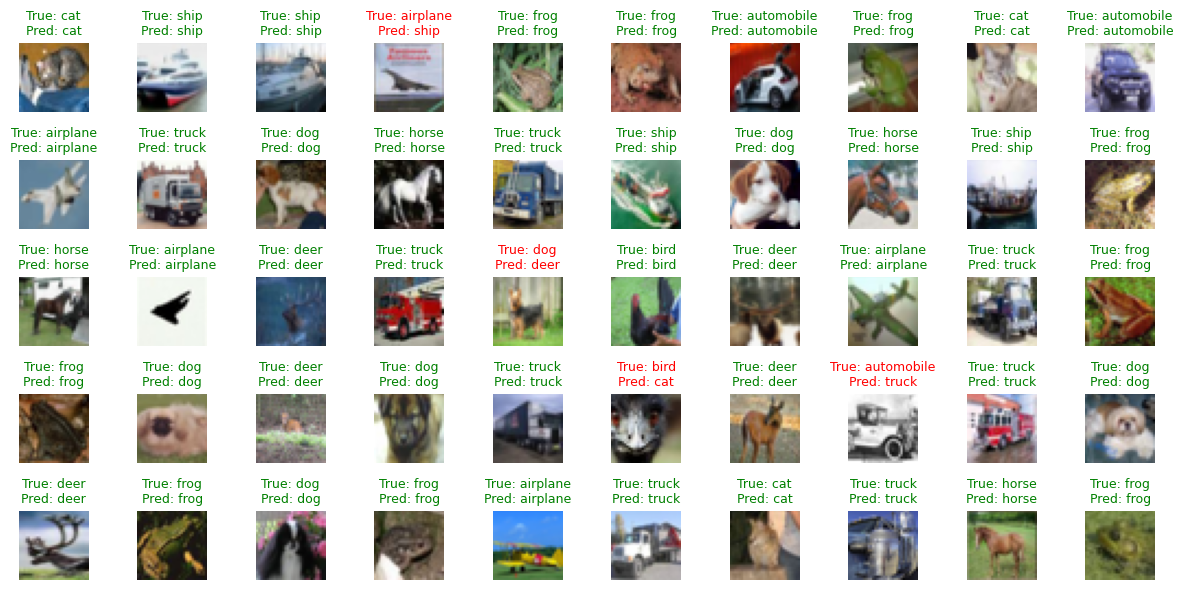

In [40]:
import matplotlib.pyplot as plt
import torch
import torchvision
import numpy as np

# Unnormalize helper
def denorm(img_tensor, mean, std):
    """Convert normalised tensor back to numpy image (0-1)."""
    img = img_tensor.clone()
    for t, m, s in zip(img, mean, std):
        t.mul_(s).add_(m)
    img = img.permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    return img

# Load the best model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AlexNetCIFAR(num_classes=10, dropout_rate=final_dropout).to(device)
model.load_state_dict(torch.load("saved/best_alexnet_cifar.pth", map_location=device))
model.eval()

# Get a batch from test_loader (test_set uses transform_test)
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    outputs = model(images)
    _, preds = torch.max(outputs, 1)


# Display a grid
num_show = 50
fig, axes = plt.subplots(5, 10, figsize=(12, 6))
axes = axes.flatten()
for i in range(num_show):
    img = denorm(images[i].cpu(), CIFAR10_MEAN, CIFAR10_STD)
    true_label = cifar10_classes[labels[i]]
    pred_label = cifar10_classes[preds[i]]
    color = 'green' if labels[i] == preds[i] else 'red'
    axes[i].imshow(img)
    axes[i].set_title(f"True: {true_label}\nPred: {pred_label}", color=color, fontsize=9)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

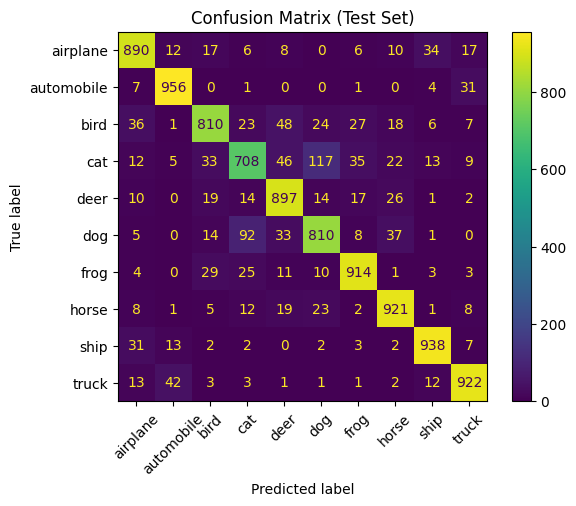

In [41]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images.to(device))
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds, labels=range(10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=cifar10_classes)
disp.plot(xticks_rotation=45)
plt.title("Confusion Matrix (Test Set)")
plt.show()

### 8. Results & Conclusions

- **Best validation accuracy**: **81.26%**
- The final model demonstrates robust performance on CIFAR-10, reaching an accuracy competitive with a baseline AlexNet for this dataset.
- The hyperparameter search revealed that **dropout** and **learning rate** are critical for generalisation.
- **Adam** with Xavier initialisation outperformed SGD in this configuration.
- The model’s main difficulties align with CIFAR-10’s well‑known challenges: low resolution and high intra‑class variability.

**Key takeaways**:
- Data augmentation and proper normalisation are essential for training deep networks on small images.
- Hyperparameter tuning significantly boosts performance – a simple grid search would have been far less efficient than Optuna’s Bayesian optimisation.
- The confusion matrix highlights the classes where further improvement could be targeted (e.g., fine‑grained features for cats/dogs).



## Part 2: Eurosat Dataset

### 1. Introduction and data loading

In [4]:

# Download the EuroSAT dataset from torchvision
euro_dataset = datasets.EuroSAT(root="./data", download=True, transform=None)
class_names = euro_dataset.classes

print(f"Total images: {len(euro_dataset)}")
print(f"Classes: {class_names}")

Total images: 27000
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


### 2. Exploratory data analysis

#### 2.1 Class distribution

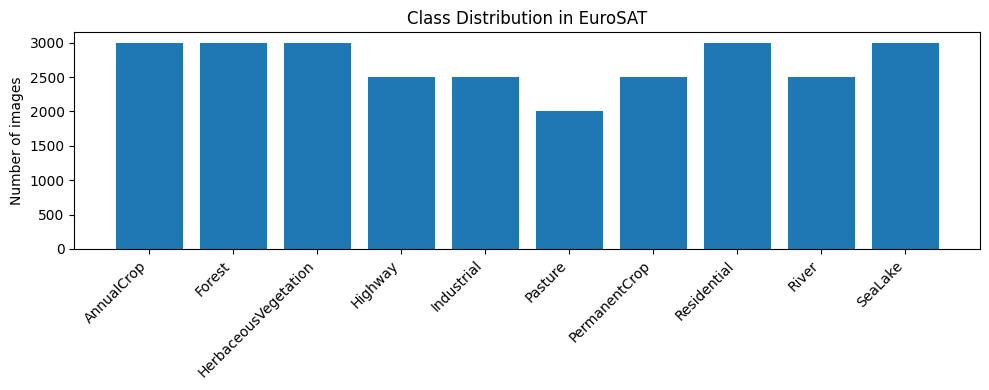

AnnualCrop                    : 3000
Forest                        : 3000
HerbaceousVegetation          : 3000
Highway                       : 2500
Industrial                    : 2500
Pasture                       : 2000
PermanentCrop                 : 2500
Residential                   : 3000
River                         : 2500
SeaLake                       : 3000


In [3]:
labels = [euro_dataset[i][1] for i in range(len(euro_dataset))]
unique, counts = np.unique(labels, return_counts=True)

plt.figure(figsize=(10, 4))
plt.bar([class_names[i] for i in unique], counts)
plt.title("Class Distribution in EuroSAT")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Number of images")
plt.tight_layout()
plt.show()

for i, cnt in zip(unique, counts):
    print(f"{class_names[i]:30s}: {cnt}")

#### 2.2 Sample per class

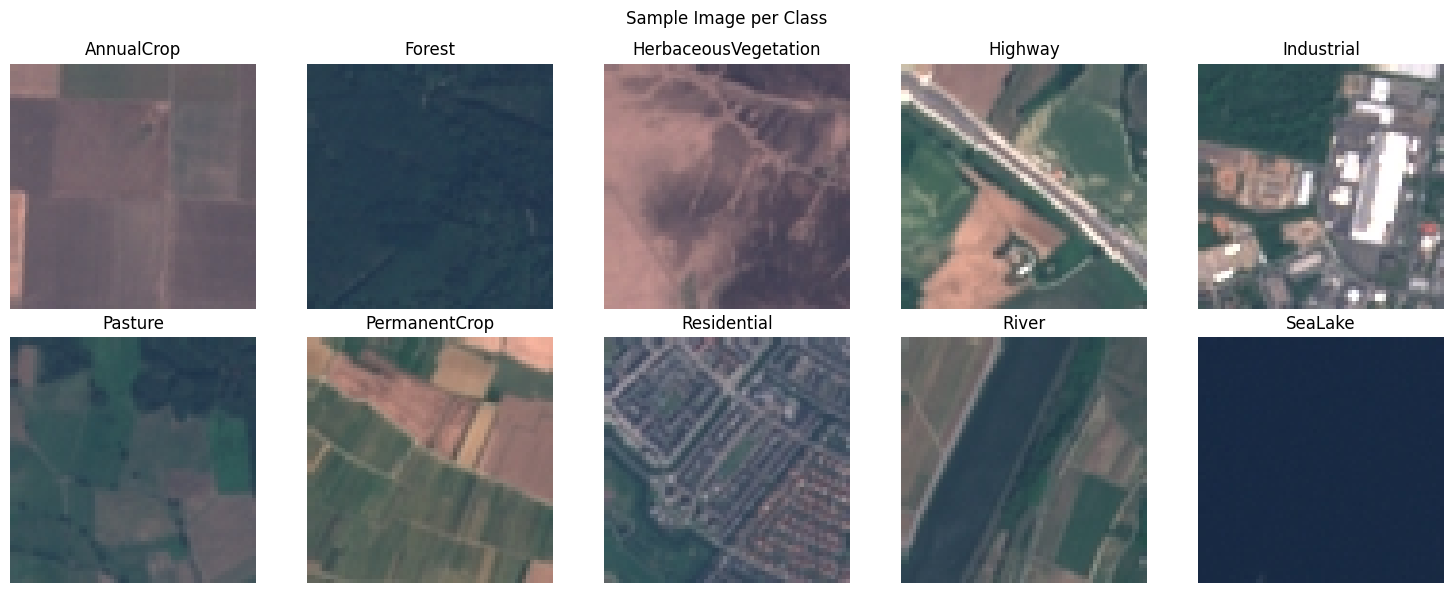

In [4]:
# Grab the first occurrence of each class
idx_per_class = {}
for idx in range(len(euro_dataset)):
    cl = euro_dataset[idx][1]
    if cl not in idx_per_class:
        idx_per_class[cl] = idx
    if len(idx_per_class) == len(class_names):
        break

plt.figure(figsize=(15, 6))
for i, cl in enumerate(sorted(idx_per_class.keys())):
    img, _ = euro_dataset[idx_per_class[cl]]
    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(class_names[cl])
    plt.axis('off')
plt.suptitle("Sample Image per Class")
plt.tight_layout()
plt.show()

#### 2.3 RGB pixel intensity histogram

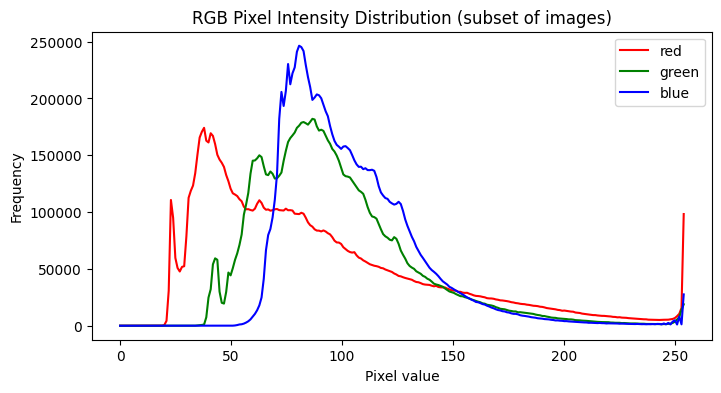

In [ ]:
# Use a random subset of 3000 images 
np.random.seed(42)
num_samples = min(3000, len(euro_dataset))
subset_indices = np.random.choice(len(euro_dataset), num_samples, replace=False)

all_pixels = []
for i in subset_indices:
    img = np.array(euro_dataset[i][0])
    all_pixels.append(img.reshape(-1, 3))
all_pixels = np.concatenate(all_pixels, axis=0)

colors = ('red', 'green', 'blue')
plt.figure(figsize=(8, 4))
for c, color in enumerate(colors):
    hist, bins = np.histogram(all_pixels[:, c], bins=256, range=(0, 255))
    plt.plot(bins[:-1], hist, color=color, label=color)
plt.title("RGB Pixel Intensity Distribution (subset of images)")
plt.xlabel("Pixel value")
plt.ylabel("Frequency")
plt.legend()
plt.show()

### 3. Data preparation 

In [5]:
from sklearn.model_selection import train_test_split

# Get all labels (euro_dataset.targets is a list of ints from 0 to 9)
labels = euro_dataset.targets

# Split indices into train (80%) and temp (20%) – keep class ratios
train_indices, temp_indices = train_test_split(
    np.arange(len(labels)),
    test_size=0.2,
    stratify=labels,
    random_state=42
)

# Split temp indices equally into validation (10%) and test (10%)
temp_labels = [labels[i] for i in temp_indices]
val_indices, test_indices = train_test_split(
    temp_indices,
    test_size=0.5,
    stratify=temp_labels,
    random_state=42
)

# Create Subsets
from torch.utils.data import Subset

train_subset = Subset(euro_dataset, train_indices)
val_subset   = Subset(euro_dataset, val_indices)
test_subset  = Subset(euro_dataset, test_indices)

print(f"Train: {len(train_subset)}, Validation: {len(val_subset)}, Test: {len(test_subset)}")

Train: 21600, Validation: 2700, Test: 2700


In [6]:
class SubsetWithTransform(Dataset):
    """Wraps a random_split subset and applies a transform."""
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        img, label = self.subset[idx]
        if self.transform:
            img = self.transform(img)
        return img, label
    

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
IMG_SIZE = 224

# Training: resize + light augmentation + normalise
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

# Validation / Test: only resize and normalise
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

train_dataset = SubsetWithTransform(train_subset, train_transform)
val_dataset   = SubsetWithTransform(val_subset,   eval_transform)
test_dataset  = SubsetWithTransform(test_subset,  eval_transform)

BATCH_SIZE = 128


train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                        num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

Train batches: 169
Val batches:   22
Test batches:  22


### 4. Models Definition

In [31]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
from models.AlexNetEuroSAT import AlexNetEuroSAT

# --- Model 4.1: AlexNet---
model_alexnet_scratch = AlexNetEuroSAT(num_classes=10, dropout_rate=0.5).to(device)



In [32]:
def get_training_essentials(model):
    criterion = nn.CrossEntropyLoss()
    # Hiperparámetros de la guía: LR=0.01, Momentum=0.9, Weight Decay=5e-4
    optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
    # Scheduler: Reduce LR en épocas 30 y 60 (ajustable según épocas totales)
    scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[15, 30], gamma=0.1)
    return criterion, optimizer, scheduler

In [33]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=80):
    
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    for epoch in range(num_epochs):
        model.train()
        running_loss, correct = 0.0, 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += torch.sum(preds == labels.data)
        
        scheduler.step()
        
        # Metrics of the epoch
        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = correct.double() / len(train_loader.dataset)
        
        # Validation
        model.eval()
        val_loss, val_correct = 0.0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                val_correct += torch.sum(preds == labels.data)
        
        v_loss = val_loss / len(val_loader.dataset)
        v_acc = val_correct.double() / len(val_loader.dataset)
        
        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(epoch_acc.item())
        history['val_loss'].append(v_loss)
        history['val_acc'].append(v_acc.item())
        
        print(f'Epoch {epoch+1}/{num_epochs} | Train Acc: {epoch_acc:.4f} | Val Acc: {v_acc:.4f}')
        
    return history

Now, we are going to train the AlexNet model that we previously made, but with some modifications to adapt it to this datasets images.

In [34]:
print("Starting AlexNet training from scratch...")

criterion_alexnet_scratch, optimizer_alexnet_scratch, scheduler_alexnet_scratch = get_training_essentials(model_alexnet_scratch)

# 2. Call the training function
history_alexnet = train_model(
    model_alexnet_scratch, train_loader, val_loader, 
    criterion_alexnet_scratch, optimizer_alexnet_scratch, scheduler_alexnet_scratch, 
    num_epochs=30
)

torch.save(model_alexnet_scratch.state_dict(), 'alexnet_scratch_eurosat.pth')

Starting AlexNet training from scratch...
Epoch 1/30 | Train Acc: 0.6107 | Val Acc: 0.5696
Epoch 2/30 | Train Acc: 0.7476 | Val Acc: 0.6415
Epoch 3/30 | Train Acc: 0.7948 | Val Acc: 0.7719
Epoch 4/30 | Train Acc: 0.8154 | Val Acc: 0.7574
Epoch 5/30 | Train Acc: 0.8389 | Val Acc: 0.7937
Epoch 6/30 | Train Acc: 0.8508 | Val Acc: 0.8348
Epoch 7/30 | Train Acc: 0.8704 | Val Acc: 0.7511
Epoch 8/30 | Train Acc: 0.8804 | Val Acc: 0.8904
Epoch 9/30 | Train Acc: 0.8937 | Val Acc: 0.7944
Epoch 10/30 | Train Acc: 0.8932 | Val Acc: 0.8930
Epoch 11/30 | Train Acc: 0.9012 | Val Acc: 0.7493
Epoch 12/30 | Train Acc: 0.9107 | Val Acc: 0.9056
Epoch 13/30 | Train Acc: 0.9191 | Val Acc: 0.8967
Epoch 14/30 | Train Acc: 0.9172 | Val Acc: 0.9178
Epoch 15/30 | Train Acc: 0.9257 | Val Acc: 0.8233
Epoch 16/30 | Train Acc: 0.9474 | Val Acc: 0.9589
Epoch 17/30 | Train Acc: 0.9565 | Val Acc: 0.9537
Epoch 18/30 | Train Acc: 0.9564 | Val Acc: 0.9574
Epoch 19/30 | Train Acc: 0.9575 | Val Acc: 0.9596
Epoch 20/30 | Tra

# CAMBIOS

In [20]:
import time
from torchinfo import summary  # optional: install with pip install torchinfo

def count_trainable_params(model):
    """Return number of trainable parameters."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def train_transfer_model(
    model, train_loader, val_loader, num_classes=10,
    mode="feature_extraction", unfreeze_layers=None,
    lr=1e-3, lr_finetune=1e-5, epochs=15, device="cuda"
):
    # --- Freeze / unfreeze logic (exactly as before) ---
    if mode == "feature_extraction":
        for param in model.parameters():
            param.requires_grad = False
        if hasattr(model, 'classifier'):
            for param in model.classifier.parameters():
                param.requires_grad = True
        elif hasattr(model, 'fc'):
            for param in model.fc.parameters():
                param.requires_grad = True
        current_lr = lr
    else:  # finetune
        if unfreeze_layers is not None:
            for name, param in model.named_parameters():
                if any(layer_name in name for layer_name in unfreeze_layers):
                    param.requires_grad = True
        else:
            for param in model.parameters():
                param.requires_grad = True
        current_lr = lr_finetune

    # --- Optimizer (unchanged) ---
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=current_lr
    )
    criterion = nn.CrossEntropyLoss()
    scaler = torch.amp.GradScaler()          # <-- new

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [],
               'epoch_time': []}

    for epoch in range(epochs):
        start = time.time()
        model.train()
        running_loss, correct = 0.0, 0

        for inputs, labels in train_loader:
            inputs = inputs.to(device, non_blocking=True)   # <-- non_blocking
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad()

            with torch.amp.autocast('cuda'):                # <-- AMP
                outputs = model(inputs)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()                  # <-- scale loss
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()

        train_loss = running_loss / len(train_loader.dataset)
        train_acc = correct / len(train_loader.dataset)

        # Validation (with AMP as well, though not strictly necessary)
        model.eval()
        val_loss, val_correct = 0.0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)
                with torch.amp.autocast('cuda'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()

        val_loss /= len(val_loader.dataset)
        val_acc = val_correct / len(val_loader.dataset)
        epoch_time = time.time() - start

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['epoch_time'].append(epoch_time)

        print(f"{mode} Epoch {epoch+1}/{epochs} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Time: {epoch_time:.1f}s")

    return history

In [24]:
print("\n====== VGG16 Transfer Learning ======")
model_vgg16 = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
# Replace the classifier head (the last linear layer is classifier[6])
in_features = model_vgg16.classifier[6].in_features
model_vgg16.classifier[6] = nn.Linear(in_features, 10)
model_vgg16 = model_vgg16.to(device)

# Stage 1: feature extraction
hist_vgg16_fe = train_transfer_model(
    model_vgg16, train_loader, val_loader, num_classes=10,
    mode="feature_extraction", lr=1e-3, epochs=15, device=device
)

# Stage 2: fine‑tuning (unfreeze the last convolutional block of VGG16)
# VGG16 features: layers 0-30. The last conv block starts at index 24.
hist_vgg16_ft = train_transfer_model(
    model_vgg16, train_loader, val_loader, num_classes=10,
    mode="finetune", unfreeze_layers=["features.24", "features.26", "features.28"],
    lr=1e-5, epochs=15, device=device
)

torch.save(model_vgg16.state_dict(), "saved/vgg16_eurosat.pth")


====== VGG16 Transfer Learning ======
feature_extraction Epoch 1/15 | Train Acc: 0.7882 | Val Acc: 0.9030 | Time: 73.1s
feature_extraction Epoch 2/15 | Train Acc: 0.8709 | Val Acc: 0.9137 | Time: 58.2s
feature_extraction Epoch 3/15 | Train Acc: 0.8838 | Val Acc: 0.9248 | Time: 58.2s
feature_extraction Epoch 4/15 | Train Acc: 0.8912 | Val Acc: 0.9237 | Time: 56.4s
feature_extraction Epoch 5/15 | Train Acc: 0.8981 | Val Acc: 0.9289 | Time: 54.9s
feature_extraction Epoch 6/15 | Train Acc: 0.8993 | Val Acc: 0.9333 | Time: 57.9s
feature_extraction Epoch 7/15 | Train Acc: 0.9069 | Val Acc: 0.9344 | Time: 55.0s
feature_extraction Epoch 8/15 | Train Acc: 0.9078 | Val Acc: 0.9248 | Time: 58.0s
feature_extraction Epoch 9/15 | Train Acc: 0.9142 | Val Acc: 0.9270 | Time: 57.8s
feature_extraction Epoch 10/15 | Train Acc: 0.9159 | Val Acc: 0.9367 | Time: 55.0s
feature_extraction Epoch 11/15 | Train Acc: 0.9168 | Val Acc: 0.9396 | Time: 57.8s
feature_extraction Epoch 12/15 | Train Acc: 0.9192 | Val 

In [23]:
print("\n====== ResNet-50 Transfer Learning ======")
model_resnet50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
# Replace the fully connected layer
in_features = model_resnet50.fc.in_features
model_resnet50.fc = nn.Linear(in_features, 10)
model_resnet50 = model_resnet50.to(device)

# Stage 1: feature extraction
hist_resnet50_fe = train_transfer_model(
    model_resnet50, train_loader, val_loader, num_classes=10,
    mode="feature_extraction", lr=1e-3, epochs=15, device=device
)

# Stage 2: fine‑tuning (unfreeze the last residual block, layer4)
hist_resnet50_ft = train_transfer_model(
    model_resnet50, train_loader, val_loader, num_classes=10,
    mode="finetune", unfreeze_layers=["layer4"],
    lr=1e-5, epochs=15, device=device
)

torch.save(model_resnet50.state_dict(), "saved/resnet50_eurosat.pth")


====== ResNet-50 Transfer Learning ======
feature_extraction Epoch 1/15 | Train Acc: 0.7778 | Val Acc: 0.8444 | Time: 27.3s
feature_extraction Epoch 2/15 | Train Acc: 0.8784 | Val Acc: 0.8870 | Time: 27.0s
feature_extraction Epoch 3/15 | Train Acc: 0.8975 | Val Acc: 0.9007 | Time: 27.0s
feature_extraction Epoch 4/15 | Train Acc: 0.9102 | Val Acc: 0.9115 | Time: 23.5s
feature_extraction Epoch 5/15 | Train Acc: 0.9174 | Val Acc: 0.9130 | Time: 27.0s
feature_extraction Epoch 6/15 | Train Acc: 0.9215 | Val Acc: 0.9159 | Time: 27.1s
feature_extraction Epoch 7/15 | Train Acc: 0.9241 | Val Acc: 0.9193 | Time: 27.0s
feature_extraction Epoch 8/15 | Train Acc: 0.9281 | Val Acc: 0.9174 | Time: 23.4s
feature_extraction Epoch 9/15 | Train Acc: 0.9297 | Val Acc: 0.9263 | Time: 27.0s
feature_extraction Epoch 10/15 | Train Acc: 0.9312 | Val Acc: 0.9256 | Time: 27.0s
feature_extraction Epoch 11/15 | Train Acc: 0.9341 | Val Acc: 0.9281 | Time: 23.4s
feature_extraction Epoch 12/15 | Train Acc: 0.9353 | 

In [22]:
print("\n====== EfficientNetV2-S Transfer Learning ======")
# 1. Initialize Model
model_effnetv2 = efficientnet_v2_s(weights=EfficientNet_V2_S_Weights.DEFAULT)
model_effnetv2.classifier[1] = nn.Linear(model_effnetv2.classifier[1].in_features, 10)
model_effnetv2 = model_effnetv2.to(device)

# 2. Stage 1: Feature Extraction
hist_effnetv2_fe = train_transfer_model(
    model_effnetv2, train_loader, val_loader, num_classes=10,
    mode="feature_extraction", lr=1e-3, epochs=15, device=device
)

# 3. Stage 2: Fine-Tuning 
# Unfreezing the last few blocks of the V2 architecture
hist_effnetv2_ft = train_transfer_model(
    model_effnetv2, train_loader, val_loader, num_classes=10,
    mode="finetune", unfreeze_layers=["features.6", "features.7"],
    lr=1e-5, epochs=15, device=device
)

# 4. Save the model weights
torch.save(model_effnetv2.state_dict(), "saved/effnetv2_eurosat.pth")


====== EfficientNetV2-S Transfer Learning ======
feature_extraction Epoch 1/15 | Train Acc: 0.7311 | Val Acc: 0.7730 | Time: 29.2s
feature_extraction Epoch 2/15 | Train Acc: 0.8226 | Val Acc: 0.8170 | Time: 27.6s
feature_extraction Epoch 3/15 | Train Acc: 0.8399 | Val Acc: 0.8285 | Time: 27.6s
feature_extraction Epoch 4/15 | Train Acc: 0.8480 | Val Acc: 0.8422 | Time: 24.0s
feature_extraction Epoch 5/15 | Train Acc: 0.8534 | Val Acc: 0.8456 | Time: 27.6s
feature_extraction Epoch 6/15 | Train Acc: 0.8568 | Val Acc: 0.8552 | Time: 27.4s
feature_extraction Epoch 7/15 | Train Acc: 0.8582 | Val Acc: 0.8504 | Time: 27.5s
feature_extraction Epoch 8/15 | Train Acc: 0.8582 | Val Acc: 0.8567 | Time: 23.9s
feature_extraction Epoch 9/15 | Train Acc: 0.8660 | Val Acc: 0.8530 | Time: 27.5s
feature_extraction Epoch 10/15 | Train Acc: 0.8642 | Val Acc: 0.8600 | Time: 27.4s
feature_extraction Epoch 11/15 | Train Acc: 0.8634 | Val Acc: 0.8589 | Time: 27.6s
feature_extraction Epoch 12/15 | Train Acc: 0.

In [35]:
@torch.no_grad()
def evaluate_model(model, test_loader, device):
    model.eval()
    all_preds, all_labels = [], []
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return np.array(all_labels), np.array(all_preds)

# Dictionary of all models you want to compare
# (assuming model_alexnet_scratch and model_resnet_scratch are already trained)
models_to_evaluate = {
    "AlexNet (scratch)": model_alexnet_scratch,
    "VGG16 (transfer)": model_vgg16,
    "ResNet‑50 (transfer)": model_resnet50,
    "EfficientNetV2-S (transfer)": model_effnetv2
}

results = {}
for name, model in models_to_evaluate.items():
    true_labels, pred_labels = evaluate_model(model, test_loader, device)
    acc = (pred_labels == true_labels).mean()
    results[name] = {"labels": true_labels, "preds": pred_labels, "accuracy": acc}
    print(f"{name:25s}: Test Accuracy = {acc:.4f}")

AlexNet (scratch)        : Test Accuracy = 0.9585
VGG16 (transfer)         : Test Accuracy = 0.9493
ResNet‑50 (transfer)     : Test Accuracy = 0.9663
EfficientNetV2-S (transfer): Test Accuracy = 0.9715



Classification Report for EfficientNetV2-S (transfer)
                      precision    recall  f1-score   support

          AnnualCrop       0.95      0.97      0.96       300
              Forest       0.97      0.99      0.98       300
HerbaceousVegetation       0.95      0.98      0.97       300
             Highway       0.97      0.94      0.96       250
          Industrial       0.98      0.99      0.98       250
             Pasture       0.96      0.93      0.94       200
       PermanentCrop       0.97      0.93      0.95       250
         Residential       0.99      0.99      0.99       300
               River       0.97      0.98      0.98       250
             SeaLake       0.99      0.99      0.99       300

            accuracy                           0.97      2700
           macro avg       0.97      0.97      0.97      2700
        weighted avg       0.97      0.97      0.97      2700



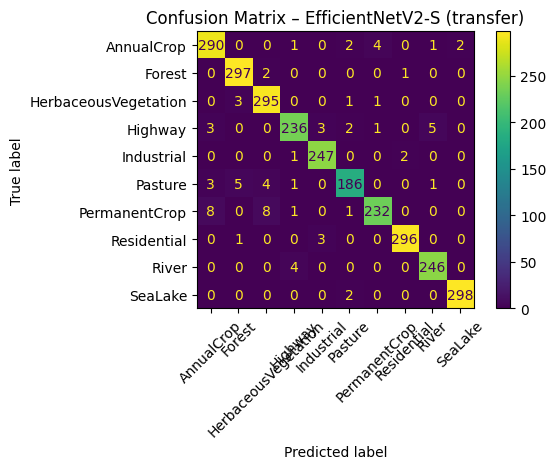

In [36]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

best_model_name = "EfficientNetV2-S (transfer)"   # change to the best performing
true_labels = results[best_model_name]["labels"]
pred_labels = results[best_model_name]["preds"]

print(f"\nClassification Report for {best_model_name}")
print(classification_report(true_labels, pred_labels, target_names=class_names))

cm = confusion_matrix(true_labels, pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(xticks_rotation=45)
plt.title(f"Confusion Matrix – {best_model_name}")
plt.tight_layout()
plt.show()

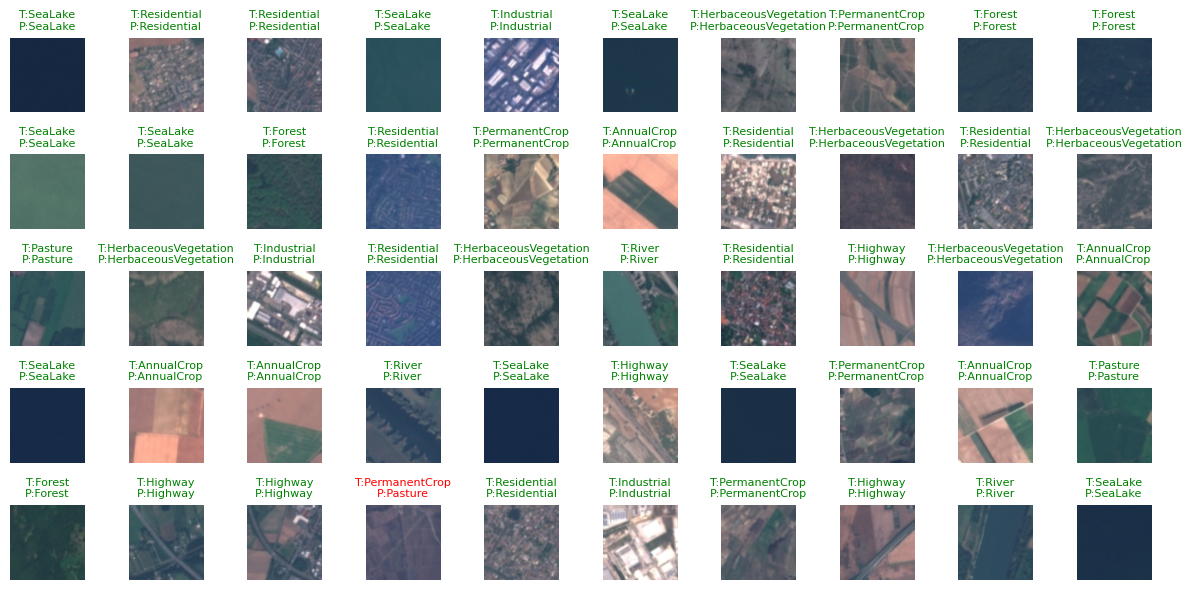

In [37]:
def denorm_eurosat(img_tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    img = img_tensor.clone().cpu()
    for t, m, s in zip(img, mean, std):
        t.mul_(s).add_(m)
    img = img.clamp_(0, 1).permute(1, 2, 0).numpy()
    return img

# Pick the model you want to see
model = model_effnetv2
model.eval()

images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

num_show = 50
fig, axes = plt.subplots(5, 10, figsize=(12, 6))
axes = axes.flatten()
for i in range(num_show):
    img = denorm_eurosat(images[i])
    true_label = class_names[labels[i]]
    pred_label = class_names[preds[i]]
    color = 'green' if labels[i] == preds[i] else 'red'
    axes[i].imshow(img)
    axes[i].set_title(f"T:{true_label}\nP:{pred_label}", color=color, fontsize=8)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

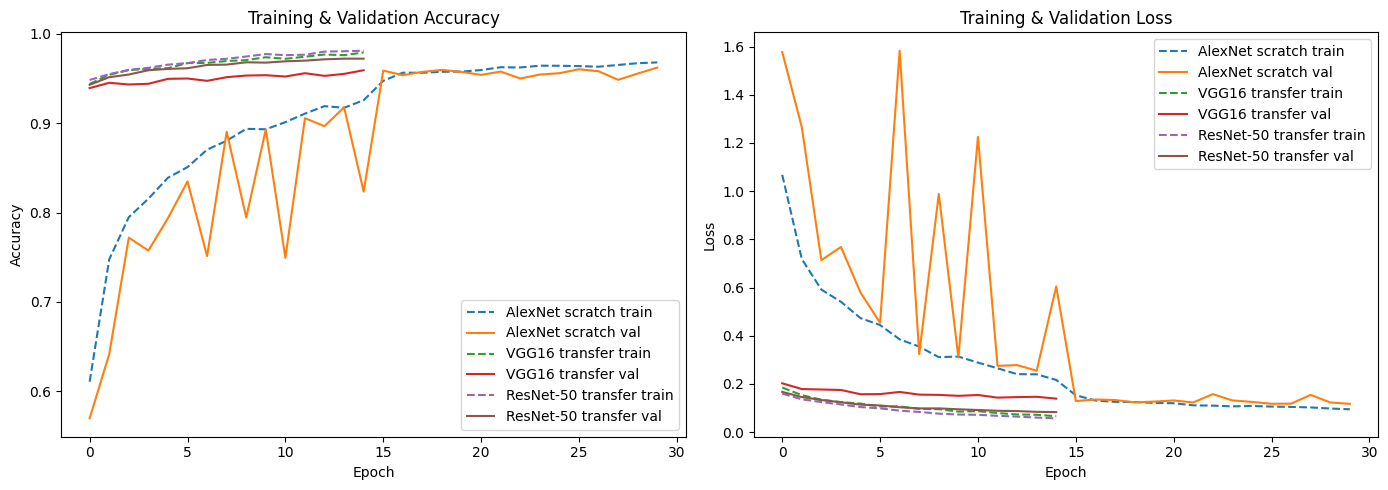

In [38]:
# Combine histories from from‑scratch models (already trained) and transfer fine‑tuning stages
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_alexnet['train_acc'], '--', label='AlexNet scratch train')
plt.plot(history_alexnet['val_acc'], '-', label='AlexNet scratch val')
plt.plot(hist_vgg16_ft['train_acc'], '--', label='VGG16 transfer train')
plt.plot(hist_vgg16_ft['val_acc'], '-', label='VGG16 transfer val')
plt.plot(hist_resnet50_ft['train_acc'], '--', label='ResNet-50 transfer train')
plt.plot(hist_resnet50_ft['val_acc'], '-', label='ResNet-50 transfer val')
plt.title("Training & Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_alexnet['train_loss'], '--', label='AlexNet scratch train')
plt.plot(history_alexnet['val_loss'], '-', label='AlexNet scratch val')
plt.plot(hist_vgg16_ft['train_loss'], '--', label='VGG16 transfer train')
plt.plot(hist_vgg16_ft['val_loss'], '-', label='VGG16 transfer val')
plt.plot(hist_resnet50_ft['train_loss'], '--', label='ResNet-50 transfer train')
plt.plot(hist_resnet50_ft['val_loss'], '-', label='ResNet-50 transfer val')
plt.title("Training & Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

Found examples for all classes.


sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


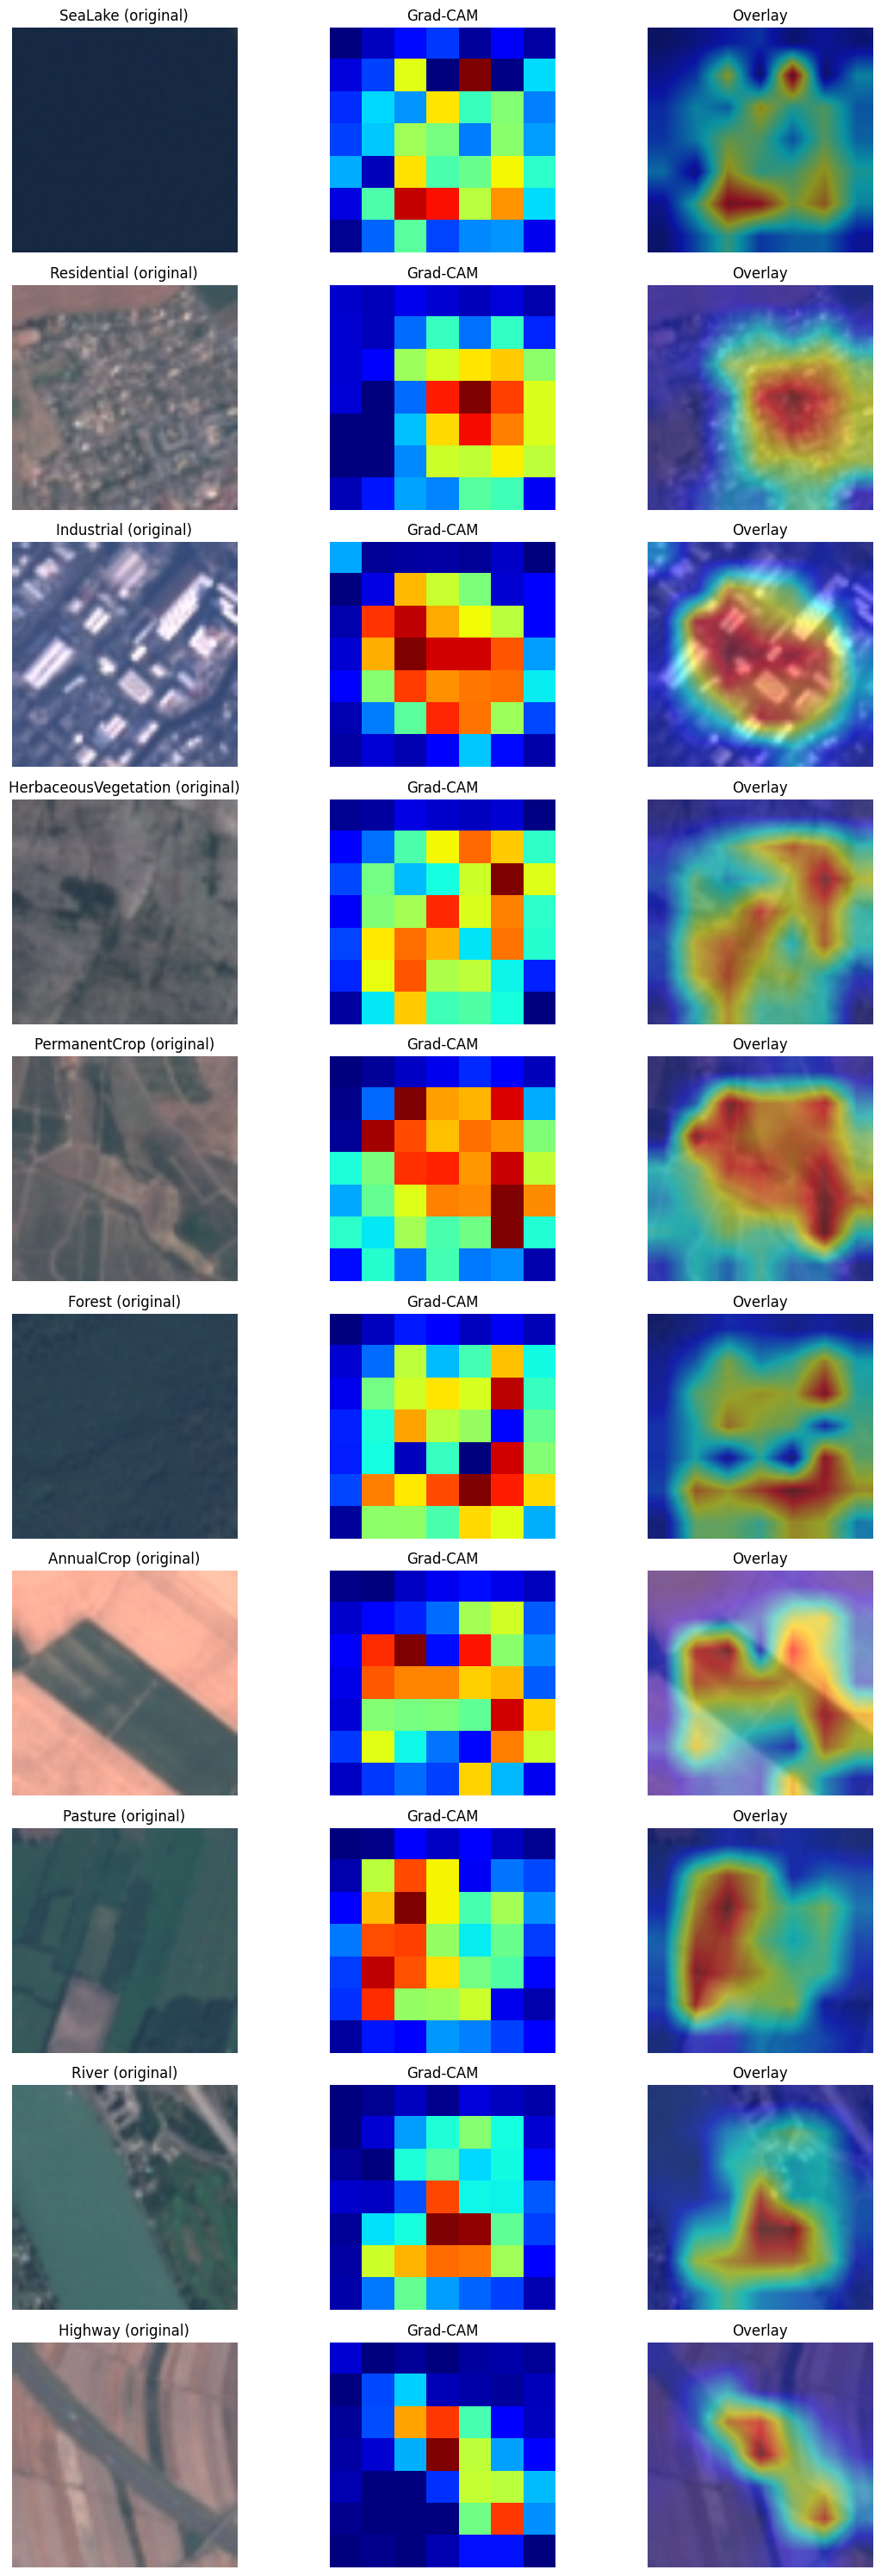

In [44]:

# ---------- utility functions (same as before, provided for completeness) ----------
def denorm_eurosat(img_tensor, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
    img = img_tensor.clone().cpu()
    for t, m, s in zip(img, mean, std):
        t.mul_(s).add_(m)
    img = img.clamp_(0, 1).permute(1, 2, 0).numpy()
    return img

def grad_cam(model, input_tensor, target_class, layer_name="features"):
    model.eval()
    activations = None
    gradients = None

    def forward_hook(module, input, output):
        nonlocal activations
        activations = output.detach()

    def backward_hook(module, grad_input, grad_output):
        nonlocal gradients
        gradients = grad_output[0].detach()

    target_layer = dict(model.named_modules())[layer_name]
    f_handle = target_layer.register_forward_hook(forward_hook)
    b_handle = target_layer.register_full_backward_hook(backward_hook)

    output = model(input_tensor)
    model.zero_grad()
    score = output[0, target_class]
    score.backward()

    f_handle.remove()
    b_handle.remove()

    weights = torch.mean(gradients, dim=(2, 3), keepdim=True)
    cam = torch.sum(weights * activations, dim=1).squeeze()
    cam = F.relu(cam)
    cam -= cam.min()
    cam /= cam.max() + 1e-8
    return cam.cpu().numpy()

def overlay_heatmap(image, heatmap, alpha=0.5, colormap=cv2.COLORMAP_JET):
    heatmap = cv2.resize(heatmap, (image.shape[1], image.shape[0]))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap), colormap)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    overlayed = alpha * heatmap_colored + (1 - alpha) * image
    return np.clip(overlayed, 0, 1)

# ---------- Load model ----------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model_effnetv2
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 10)
model.load_state_dict(torch.load("saved/effnetv2_eurosat.pth", map_location=device))
model.to(device)
model.eval()

class_names = euro_dataset.classes

# ---------- Collect one correct example per class ----------
found = {c: False for c in range(10)}
examples = []  # (image_tensor, true_label, img_original_np)

# We'll loop through the test loader until we have one per class
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        for i in range(len(labels)):
            c = labels[i].item()
            if preds[i] == c and not found[c]:
                found[c] = True
                # Keep the raw normalised tensor (for Grad‑CAM) and the denormalised image
                img_tensor = images[i].unsqueeze(0)          # (1, C, H, W)
                img_np = denorm_eurosat(images[i].cpu())     # (H, W, 3)
                examples.append((img_tensor, c, img_np))
        if all(found.values()):
            break

print("Found examples for all classes.")

# ---------- Plot ----------
fig, axes = plt.subplots(10, 3, figsize=(12, 30))
for idx, (img_tensor, true_class, img_np) in enumerate(examples):
    # Compute Grad‑CAM for the true class
    heatmap = grad_cam(model, img_tensor, target_class=true_class)
    overlayed = overlay_heatmap(img_np, heatmap, alpha=0.5)

    # Row: original – heatmap – overlay
    axes[idx, 0].imshow(img_np)
    axes[idx, 0].set_title(f"{class_names[true_class]} (original)")
    axes[idx, 0].axis('off')

    axes[idx, 1].imshow(heatmap, cmap='jet')
    axes[idx, 1].set_title("Grad‑CAM")
    axes[idx, 1].axis('off')

    axes[idx, 2].imshow(overlayed)
    axes[idx, 2].set_title("Overlay")
    axes[idx, 2].axis('off')

plt.tight_layout()
plt.show()